# 0. Install Required Libraries

In [1]:
!pip install dtaidistance tslearn imodels statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.5/274.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.2 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


# 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from dtaidistance import dtw
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')

# PREPROCESSING

In [3]:
df = pd.read_csv('/content/patient_vitals - patient_vitals.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df.head()

,PatientID,Timestamp,HeartRate,BloodPressureSystolic,BloodPressureDiastolic,BloodOxygenLevel,BodyTemperature,RespiratoryRate,SleepHours,StressLevel,Age,Gender,Diagnosis
0,P0001,2024-01-01 00:00:00,83.2,153.9,90.6,96.3,36.58,16.0,6.2,6,38,M,Hypertension
1,P0001,2024-01-01 06:00:00,81.2,172.5,110.3,95.0,36.88,16.5,5.8,3,38,M,Hypertension
2,P0001,2024-01-01 12:00:00,94.9,154.7,100.8,97.3,36.95,16.4,6.0,6,38,M,Hypertension
3,P0001,2024-01-01 18:00:00,86.6,153.3,97.7,96.4,36.47,18.9,7.6,5,38,M,Hypertension
4,P0001,2024-01-02 00:00:00,83.8,140.7,94.7,96.6,37.16,17.6,4.6,2,38,M,Hypertension


In [4]:
print(df[['PatientID','Timestamp','Diagnosis']].isnull().sum())

PatientID    0
Timestamp    0
Diagnosis    0
dtype: int64


# Apply Physiological Filters

In [5]:
before = len(df)

filters = (
    (df['HeartRate'].between(40,180)) &
    (df['BloodPressureSystolic'].between(80,200)) &
    (df['BloodPressureDiastolic'].between(50,130)) &
    (df['BloodOxygenLevel'].between(85,100)) &
    (df['BodyTemperature'].between(35.5,41.0)) &
    (df['RespiratoryRate'].between(10,40)) &
    (df['SleepHours'].between(2,12))
)

df = df[filters]
after = len(df)

print("Rows dropped:", before - after)

Rows dropped: 788


In [6]:
df = df.sort_values(['PatientID','Timestamp'])

# 6. Create Patient-Level Features

In [7]:
features = df.groupby('PatientID').agg({
    'HeartRate':['mean','std','min','max'],
    'BloodPressureSystolic':['mean','std','min','max'],
    'BloodPressureDiastolic':['mean','std'],
    'BloodOxygenLevel':['mean','std'],
    'SleepHours':['mean','std'],
    'StressLevel':['mean'],
    'RespiratoryRate':['mean']
})

features.columns = ['_'.join(col) for col in features.columns]

# Trend slope
def slope(x):
    return np.polyfit(range(len(x)), x, 1)[0]

slopes = df.groupby('PatientID')['HeartRate'].apply(slope)
features['HeartRate_trend'] = slopes

# Add labels
labels = df.groupby('PatientID')['Diagnosis'].first()
features['Diagnosis'] = labels

features.reset_index(inplace=True)

# 7. Report Stats

In [8]:
print("Total rows:", len(df))
print("Unique patients:", df['PatientID'].nunique())
print(df['Diagnosis'].value_counts(normalize=True)*100)

Total rows: 59212
Unique patients: 500
Diagnosis
Healthy           33.018645
Hypertension      24.907113
Diabetes          18.602648
Arrhythmia        15.638722
Sleep Disorder     7.832872
Name: proportion, dtype: float64


# PART A: TIME SERIES
# A1: Visualization + Stats

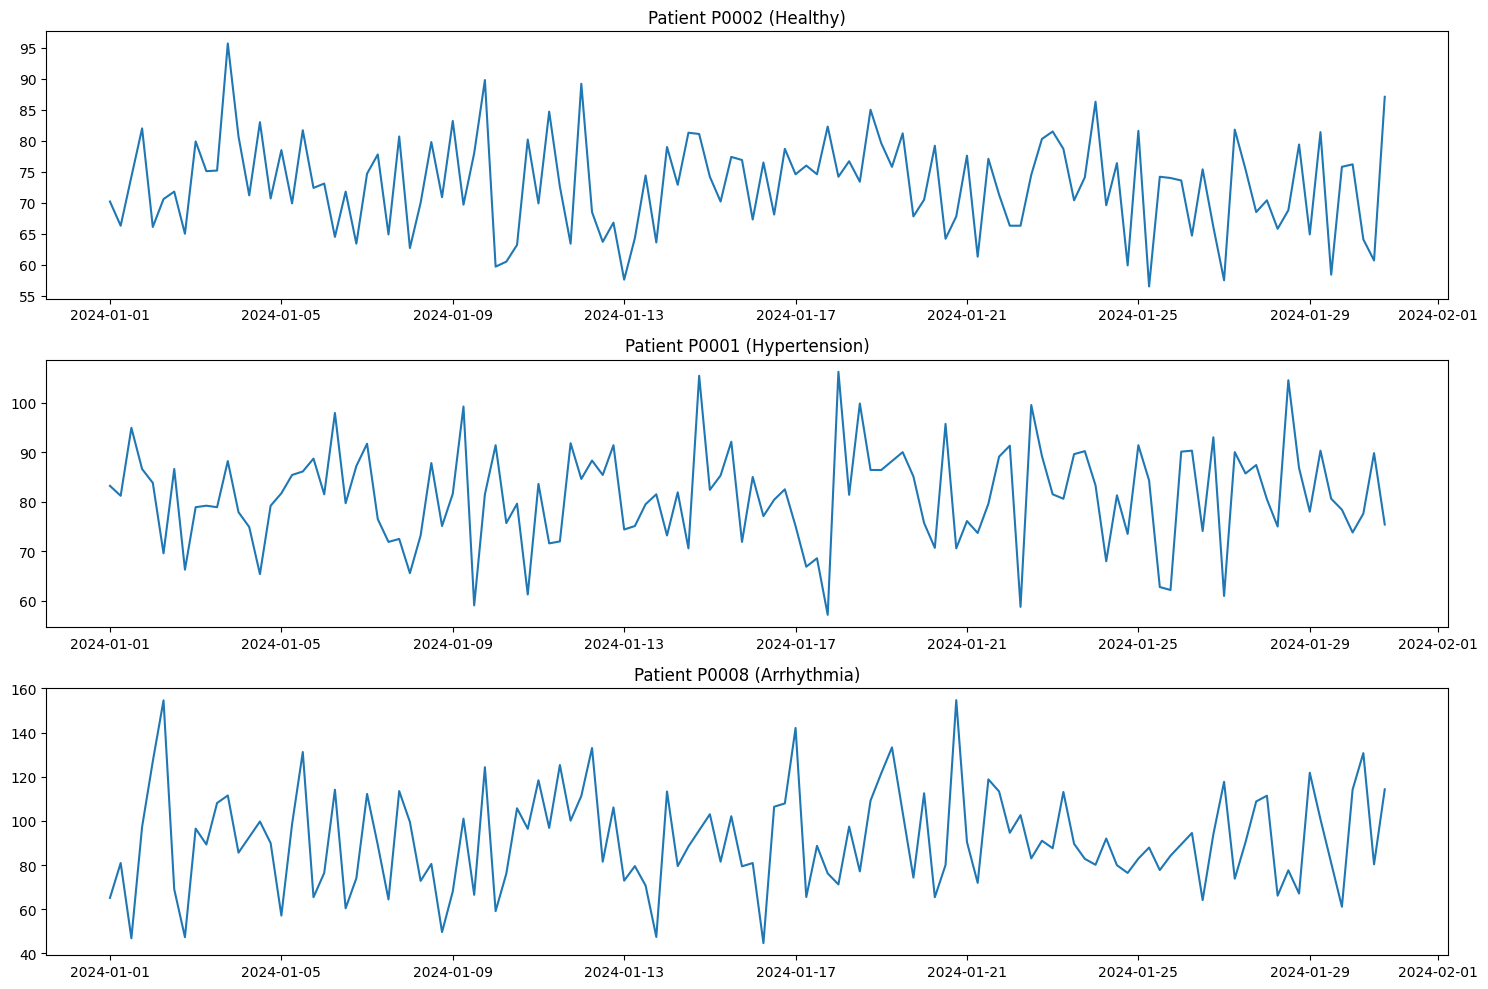

P0002 Mean: 72.9825 Std: 7.64314008350851 Min: 56.5 Max: 95.7 CV: 10.472565455429054
P0001 Mean: 81.21666666666667 Std: 9.938561968695584 Min: 57.2 Max: 106.2 CV: 12.23709661649364
P0008 Mean: 91.40695652173912 Std: 22.97930312770462 Min: 44.6 Max: 154.7 CV: 25.139556114899747


In [9]:
patients = df.groupby('Diagnosis')['PatientID'].first().to_dict()

selected = [patients['Healthy'], patients['Hypertension'], patients['Arrhythmia']]

plt.figure(figsize=(15,10))

for i, pid in enumerate(selected):
    temp = df[df['PatientID']==pid]
    plt.subplot(3,1,i+1)
    plt.plot(temp['Timestamp'], temp['HeartRate'])
    plt.title(f"Patient {pid} ({temp['Diagnosis'].iloc[0]})")

plt.tight_layout()
plt.show()

# Stats
for pid in selected:
    temp = df[df['PatientID']==pid]['HeartRate']
    print(pid,
          "Mean:", temp.mean(),
          "Std:", temp.std(),
          "Min:", temp.min(),
          "Max:", temp.max(),
          "CV:", (temp.std()/temp.mean())*100)

# A2: Rolling Mean + Decomposition

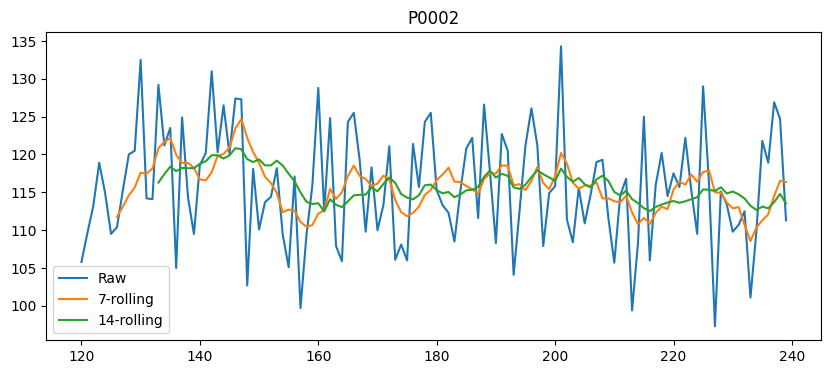

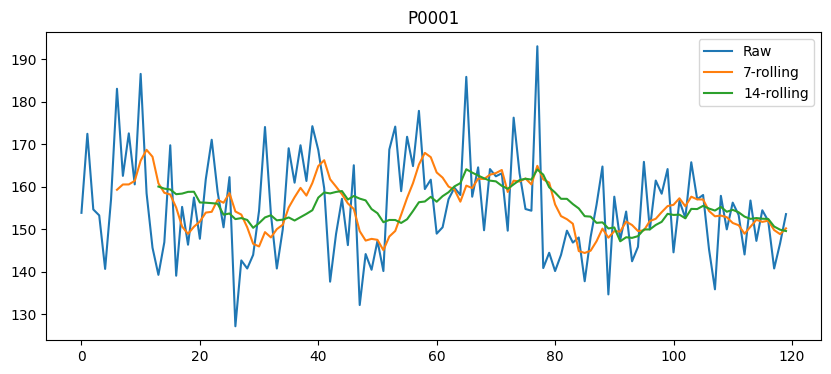

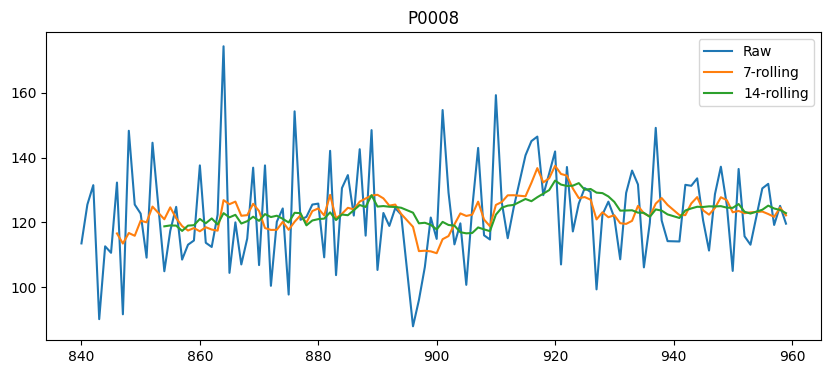

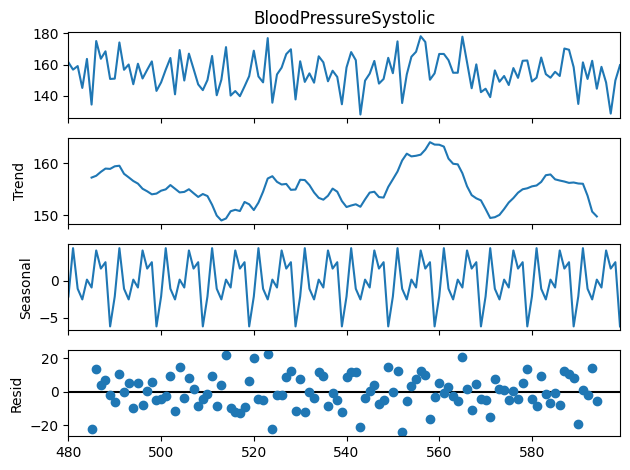

In [10]:
for pid in selected:
    temp = df[df['PatientID']==pid]

    plt.figure(figsize=(10,4))
    plt.plot(temp['BloodPressureSystolic'], label='Raw')
    plt.plot(temp['BloodPressureSystolic'].rolling(7).mean(), label='7-rolling')
    plt.plot(temp['BloodPressureSystolic'].rolling(14).mean(), label='14-rolling')
    plt.legend()
    plt.title(pid)
    plt.show()

# Decomposition
longest = df['PatientID'].value_counts().idxmax()
series = df[df['PatientID']==longest]['BloodPressureSystolic']

decomp = seasonal_decompose(series, model='additive', period=10)

decomp.plot()
plt.show()

# A3: Anomaly Detection

Total anomalies: 2629
[('P0017', np.int64(9)), ('P0029', np.int64(9)), ('P0095', np.int64(9)), ('P0344', np.int64(9)), ('P0348', np.int64(9))]


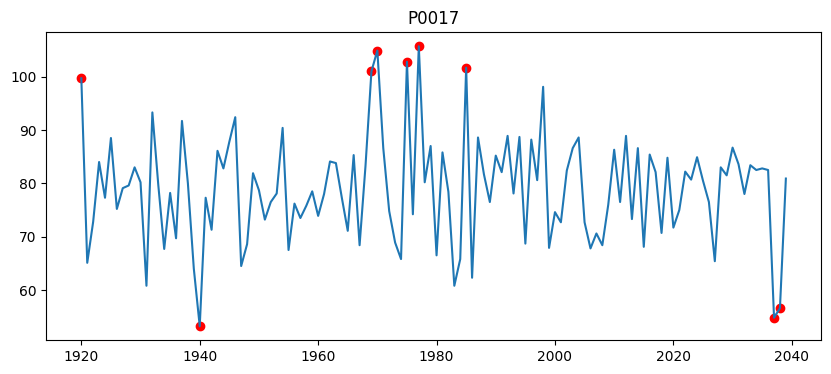

In [11]:
anomaly_counts = {}

df['Anomaly'] = False

for pid in df['PatientID'].unique():
    temp = df[df['PatientID']==pid]
    mu = temp['HeartRate'].mean()
    sigma = temp['HeartRate'].std()

    cond = (temp['HeartRate'] > mu + 2*sigma) | (temp['HeartRate'] < mu - 2*sigma)
    df.loc[temp.index, 'Anomaly'] = cond

    anomaly_counts[pid] = cond.sum()

print("Total anomalies:", df['Anomaly'].sum())

# Top 5 patients
top5 = sorted(anomaly_counts.items(), key=lambda x:x[1], reverse=True)[:5]
print(top5)

# Plot one
pid = top5[0][0]
temp = df[df['PatientID']==pid]

plt.figure(figsize=(10,4))
plt.plot(temp['HeartRate'])
plt.scatter(temp.index[temp['Anomaly']], temp['HeartRate'][temp['Anomaly']], color='red')
plt.title(pid)
plt.show()

# PART B: SIMILARITY
# Normalize Features

In [12]:
X = features.drop(['PatientID','Diagnosis'], axis=1)
y = features['Diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# B1: Euclidean & Manhattan

In [13]:
from scipy.spatial.distance import cdist

np.random.seed(42)
queries = np.random.choice(len(X_scaled), 10, replace=False)

for q in queries:
    d_euc = cdist([X_scaled[q]], X_scaled, metric='euclidean')[0]
    d_man = cdist([X_scaled[q]], X_scaled, metric='cityblock')[0]

    nn_euc = np.argsort(d_euc)[1:4]
    nn_man = np.argsort(d_man)[1:4]

    print("\nQuery:", features.iloc[q]['PatientID'])
    print("Euclidean:", y.iloc[nn_euc].values)
    print("Manhattan:", y.iloc[nn_man].values)


Query: P0362
Euclidean: ['Healthy' 'Healthy' 'Healthy']
Manhattan: ['Healthy' 'Healthy' 'Healthy']

Query: P0074
Euclidean: ['Healthy' 'Healthy' 'Healthy']
Manhattan: ['Healthy' 'Healthy' 'Healthy']

Query: P0375
Euclidean: ['Hypertension' 'Hypertension' 'Hypertension']
Manhattan: ['Hypertension' 'Hypertension' 'Hypertension']

Query: P0156
Euclidean: ['Diabetes' 'Diabetes' 'Diabetes']
Manhattan: ['Diabetes' 'Diabetes' 'Diabetes']

Query: P0105
Euclidean: ['Healthy' 'Healthy' 'Healthy']
Manhattan: ['Healthy' 'Healthy' 'Healthy']

Query: P0395
Euclidean: ['Hypertension' 'Hypertension' 'Hypertension']
Manhattan: ['Hypertension' 'Hypertension' 'Hypertension']

Query: P0378
Euclidean: ['Diabetes' 'Diabetes' 'Diabetes']
Manhattan: ['Diabetes' 'Diabetes' 'Diabetes']

Query: P0125
Euclidean: ['Hypertension' 'Hypertension' 'Hypertension']
Manhattan: ['Hypertension' 'Hypertension' 'Hypertension']

Query: P0069
Euclidean: ['Sleep Disorder' 'Sleep Disorder' 'Sleep Disorder']
Manhattan: ['Sleep D

# B2: DTW

In [14]:
from tslearn.metrics import dtw

patients = df['PatientID'].unique()[:100]

series = []
labels = []

for pid in patients:
    temp = df[df['PatientID']==pid]['HeartRate'].values[:20]
    if len(temp)==20:
        series.append(temp)
        labels.append(df[df['PatientID']==pid]['Diagnosis'].iloc[0])

series = np.array(series)

dist_matrix = np.zeros((len(series), len(series)))

for i in range(len(series)):
    for j in range(len(series)):
        dist_matrix[i,j] = dtw(series[i], series[j])

print("DTW Done")

DTW Done


# B3: New Patient Prediction

In [15]:
new = np.array([[98,18,155,12,94,4.5,1200]])

# match feature size (adjust if needed)
new = np.pad(new, ((0,0),(0,X.shape[1]-new.shape[1])))

new_scaled = scaler.transform(new)

dist = cdist(new_scaled, X_scaled)[0]
nn = np.argsort(dist)[:5]

pred = y.iloc[nn].mode()[0]
confidence = (y.iloc[nn]==pred).mean()

print("Prediction:", pred)
print("Confidence:", confidence)

Prediction: Sleep Disorder
Confidence: 1.0


# PART C: CLASSIFICATION
# Train-Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# C1: Decision Tree

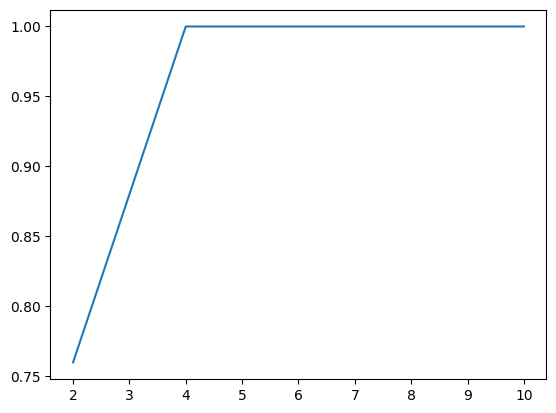

                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



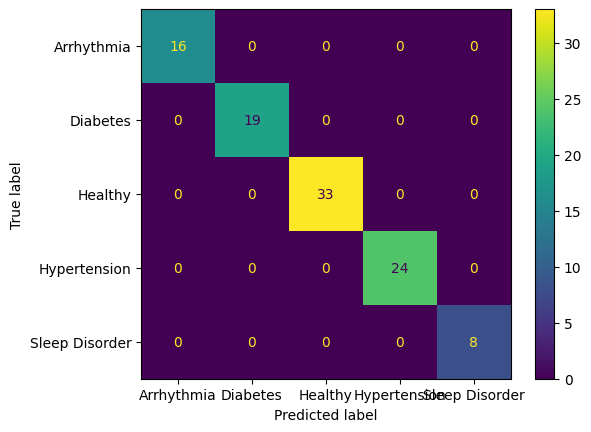

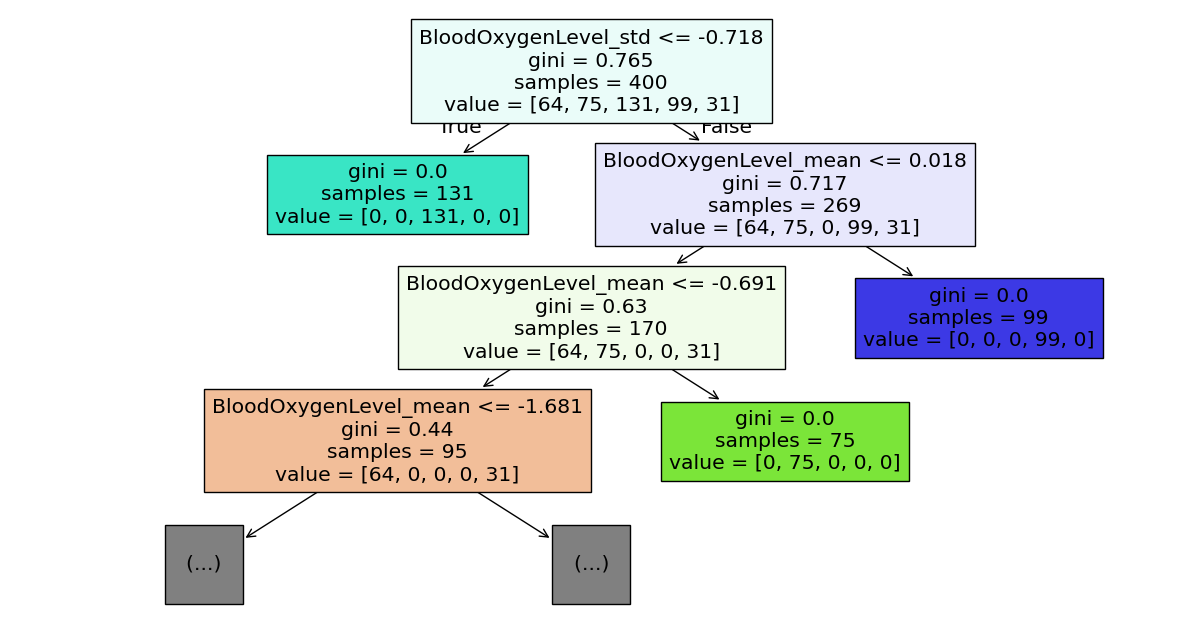

In [17]:
depths = [2,4,6,8,10]
scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

plt.plot(depths, scores)
plt.show()

dt = DecisionTreeClassifier(max_depth=6)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

plt.figure(figsize=(15,8))
plot_tree(dt, max_depth=3, feature_names=X.columns, filled=True)
plt.show()

# C2: Rule-Based Classification (Decision Tree Rule Extraction)

In [21]:
from sklearn.tree import _tree

def extract_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    paths = []

    def recurse(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            left_path = path + [f"{name} <= {threshold:.2f}"]
            recurse(tree_.children_left[node], left_path)

            right_path = path + [f"{name} > {threshold:.2f}"]
            recurse(tree_.children_right[node], right_path)
        else:
            value = tree_.value[node]
            class_id = np.argmax(value)
            paths.append((path, class_id, tree_.n_node_samples[node]))

    recurse(0, [])
    return paths

rules = extract_rules(dt, X.columns)

# Print first 10 rules
for i, (conds, class_id, samples) in enumerate(rules[:10]):
    print(f"Rule {i+1}: IF {' AND '.join(conds)} THEN class = {dt.classes_[class_id]} (samples={samples})")

Rule 1: IF BloodOxygenLevel_std <= -0.72 THEN class = Healthy (samples=131)
Rule 2: IF BloodOxygenLevel_std > -0.72 AND BloodOxygenLevel_mean <= 0.02 AND BloodOxygenLevel_mean <= -0.69 AND BloodOxygenLevel_mean <= -1.68 THEN class = Sleep Disorder (samples=31)
Rule 3: IF BloodOxygenLevel_std > -0.72 AND BloodOxygenLevel_mean <= 0.02 AND BloodOxygenLevel_mean <= -0.69 AND BloodOxygenLevel_mean > -1.68 THEN class = Arrhythmia (samples=64)
Rule 4: IF BloodOxygenLevel_std > -0.72 AND BloodOxygenLevel_mean <= 0.02 AND BloodOxygenLevel_mean > -0.69 THEN class = Diabetes (samples=75)
Rule 5: IF BloodOxygenLevel_std > -0.72 AND BloodOxygenLevel_mean > 0.02 THEN class = Hypertension (samples=99)


# C3: kNN

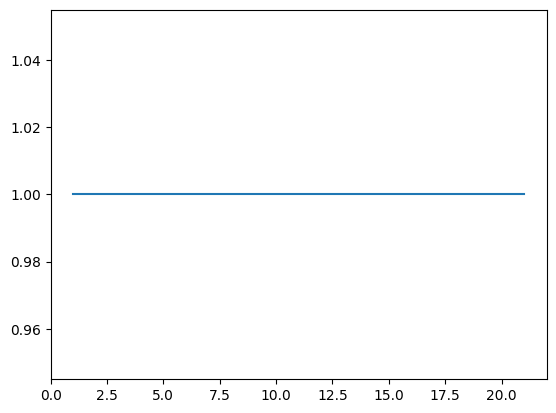

                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



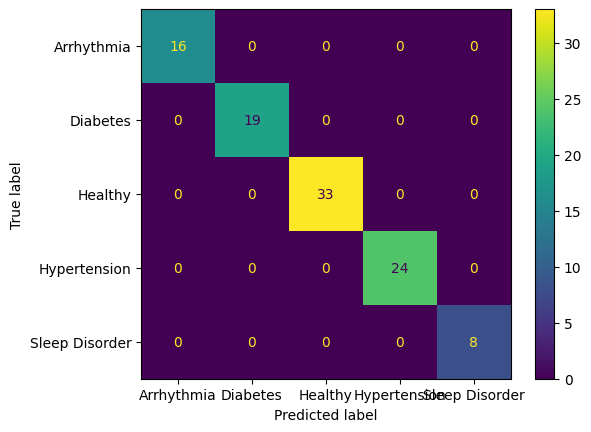

In [18]:
ks = [1,3,5,7,9,11,15,21]
scores = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.plot(ks, scores)
plt.show()

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# C4: Naive Bayes

                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



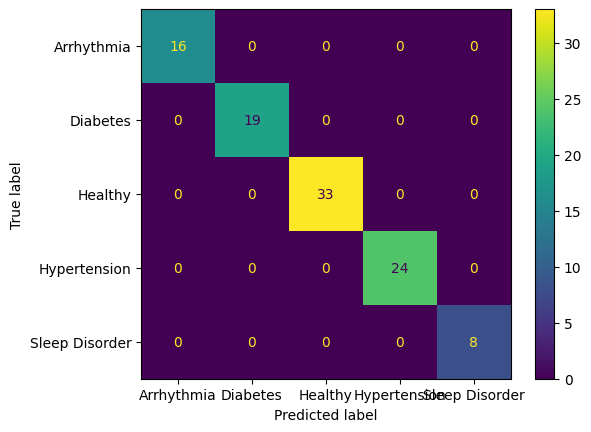

In [19]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# C5: SVM

C: 0.1 Score: 1.0
C: 1 Score: 1.0
C: 10 Score: 1.0
C: 100 Score: 1.0
                precision    recall  f1-score   support

    Arrhythmia       1.00      1.00      1.00        16
      Diabetes       1.00      1.00      1.00        19
       Healthy       1.00      1.00      1.00        33
  Hypertension       1.00      1.00      1.00        24
Sleep Disorder       1.00      1.00      1.00         8

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



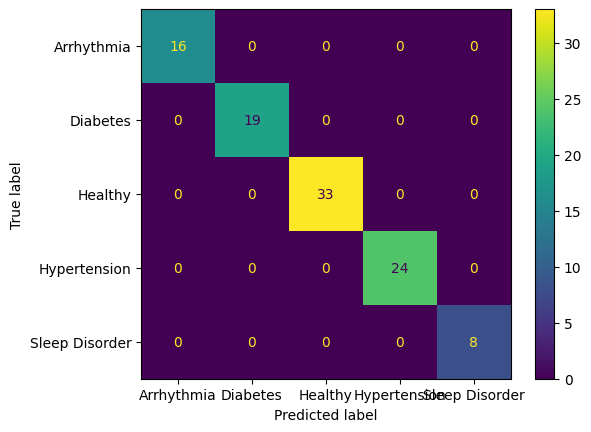

In [20]:
params = [0.1,1,10,100]

for c in params:
    svm = SVC(C=c, kernel='rbf')
    scores = cross_val_score(svm, X_train, y_train, cv=5)
    print("C:",c,"Score:",scores.mean())

svm = SVC(C=10, kernel='rbf')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()